In [1]:
import os

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import keras
import tensorflow as tf
from keras.models import Model
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

# Load Data

In [4]:
DATASET_PATH = './dataset/'

In [5]:
image_base_path = os.path.join(DATASET_PATH, 'frames')
image_base_path

'./dataset/frames'

In [6]:
mask_base_path = os.path.join(DATASET_PATH, 'lane-masks')
mask_base_path

'./dataset/lane-masks'

In [7]:
all_image_paths = []
all_mask_paths = []

In [8]:
image_filenames = os.listdir(image_base_path)

In [9]:
for file_name in image_filenames:

    if file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
        
        img_path = os.path.join(image_base_path, file_name)
        mask_path = os.path.join(mask_base_path, file_name)
        
        if os.path.exists(mask_path):
            all_image_paths.append(img_path)
            all_mask_paths.append(mask_path)

In [10]:
print({len(all_image_paths)})
print({len(all_mask_paths)})

{4759}
{4759}


In [11]:
all_image_paths[4000]

'./dataset/frames/img107.png'

In [12]:
all_mask_paths[4000]

'./dataset/lane-masks/img107.png'

In [13]:
train_images, val_images, train_masks, val_masks = train_test_split(
    all_image_paths, all_mask_paths, test_size=0.1, random_state=42)

In [14]:
len(train_images)

4283

In [15]:
len(val_images)

476

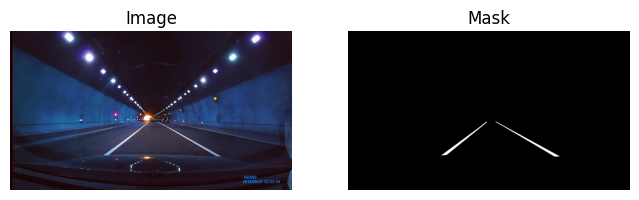

In [16]:
sample_image = train_images[200]
sample_mask = train_masks[200]

image = cv2.imread(sample_image, cv2.COLOR_BGR2RGB)
mask = cv2.imread(sample_mask, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.title("Image")
plt.imshow(image)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Mask")
plt.imshow(mask, cmap='gray') 
plt.axis('off')

plt.show()

# Masks Pixel Check

In [17]:
problematic_masks = []
all_unique_values = set()

for mask_path in all_mask_paths:
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    unique_values = np.unique(mask)
    
    all_unique_values.update(unique_values)
    
    extra_values = set(unique_values) - {0, 255}
    
    if extra_values:
        problematic_masks.append((mask_path, unique_values))

print(f"Global unique pixel values found in all masks: {sorted(list(all_unique_values))}")

Global unique pixel values found in all masks: [0, 1, 2, 3, 4, 5, 6, 7, 8, 247, 248, 249, 250, 251, 252, 253, 254, 255]


# Create Dataset

In [18]:
IMG_SIZE = (256, 256)
BATCH_SIZE = 16

In [19]:
def load_image_and_mask(image_path, mask_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)


    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.where(mask > 127, tf.cast(1, tf.uint8), tf.cast(0, tf.uint8))
    mask = tf.image.resize(mask, IMG_SIZE, method='nearest')

    return img, mask

In [20]:
def augment_photometric(image, mask):
    image = tf.image.random_brightness(image, max_delta=0.05)
    image = tf.image.random_contrast(image, lower=0.95, upper=1.05)
    image = tf.clip_by_value(image, 0.0, 255.0)
    return image, mask

In [21]:
data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.02),
], name="data_augmentation")

I0000 00:00:1758113263.637086     192 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5580 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [22]:
def augment_geometric_tf(image, mask):
    mask_float = tf.cast(mask, tf.float32)
    stacked = tf.concat([image, mask_float], axis=-1)
    augmented_stacked = data_augmentation(stacked)
    augmented_image = augmented_stacked[:, :, :3]
    augmented_mask = augmented_stacked[:, :, 3:]
    augmented_mask = tf.round(augmented_mask)
    augmented_mask = tf.cast(augmented_mask, tf.uint8)
    
    return augmented_image, augmented_mask

In [23]:
from tensorflow.keras.applications.resnet50 import preprocess_input

def final_preprocess_for_resnet(image, mask):
    image = preprocess_input(image)
    return image, mask

In [24]:
train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_masks))
train_dataset = train_dataset.map(load_image_and_mask, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.map(augment_geometric_tf, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.map(augment_photometric, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.map(final_preprocess_for_resnet, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(buffer_size=1000).batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)

In [25]:
val_dataset = tf.data.Dataset.from_tensor_slices((val_images, val_masks))
val_dataset = val_dataset.map(load_image_and_mask, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = val_dataset.map(final_preprocess_for_resnet, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)

In [26]:
print(f"Train dataset with geometric augmentation: {train_dataset}")
print(f"Validation dataset: {val_dataset}")

Train dataset with geometric augmentation: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 256, 256, 1), dtype=tf.uint8, name=None))>
Validation dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 256, 256, 1), dtype=tf.uint8, name=None))>


# Pixels Check

In [27]:
for images_batch, masks_batch in train_dataset.take(1):
    for i in range(3):
        image = images_batch[i]
        print(f"Shape: {image.shape}")
        print(f"Dtype: {image.dtype}")
        print(f"Min value: {np.min(image):.4f}")
        print(f"Max value: {np.max(image):.4f}")
        print(f"Mean value: {np.mean(image):.4f}")
        print("-" * 25)

Shape: (256, 256, 3)
Dtype: <dtype: 'float32'>
Min value: -123.6800
Max value: 151.0610
Mean value: -15.2979
-------------------------
Shape: (256, 256, 3)
Dtype: <dtype: 'float32'>
Min value: -119.1861
Max value: 143.5551
Mean value: -19.5527
-------------------------
Shape: (256, 256, 3)
Dtype: <dtype: 'float32'>
Min value: -122.1335
Max value: 151.0610
Mean value: -15.1612
-------------------------


# Imbalance Data

In [28]:
class_counts = {0: 0, 1: 0}
total_pixels = 0

for images_batch, masks_batch in train_dataset:
    for mask in masks_batch:
        mask_np = mask.numpy()
        total_pixels += mask_np.size
        unique, counts = np.unique(mask_np, return_counts=True)
        for u, c in zip(unique, counts):
            if u in class_counts:
                class_counts[u] += c

In [29]:
total_pixels

280690688

In [30]:
class_counts

{0: 270884827, 1: 9805861}

# Median Frequency Balancing 

In [31]:
class_frequencies = {cls: count / total_pixels for cls, count in class_counts.items() if count > 0}

frequencies = list(class_frequencies.values())
median_frequency = np.median(frequencies)

mfb_weights = {}
for cls, freq in class_frequencies.items():
    mfb_weights[cls] = median_frequency / freq

for cls in class_counts:
    if cls not in mfb_weights:
        mfb_weights[cls] = 0.0

print(mfb_weights)

{0: 0.5180996866982144, 1: 14.31239378163733}


# Modeling

In [32]:
from tensorflow.keras.layers import Conv2D, BatchNormalization, ReLU, Add, Input, UpSampling2D, Concatenate, AveragePooling2D, GlobalAveragePooling2D

In [33]:
def convolution_block(
    block_input,
    num_filters=256,
    kernel_size=3,
    dilation_rate=1,
    padding="same",
    use_bias=True,
):
    x = Conv2D(
        num_filters,
        kernel_size=kernel_size,
        dilation_rate=dilation_rate,
        padding="same",
        use_bias=use_bias,
    )(block_input)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    return x

In [34]:
def AtrousSpatialPyramidPooling(aspp_input):
    dims = aspp_input.shape
    x = AveragePooling2D(pool_size=(dims[1], dims[2]))(aspp_input)
    out_pool = UpSampling2D(size=(dims[1], dims[2]), interpolation="bilinear")(x)

    out_1 = convolution_block(aspp_input, kernel_size=1, dilation_rate=1)
    out_6 = convolution_block(aspp_input, kernel_size=3, dilation_rate=6)
    out_12 = convolution_block(aspp_input, kernel_size=3, dilation_rate=12)
    out_18 = convolution_block(aspp_input, kernel_size=3, dilation_rate=18)

    x = Concatenate(axis=-1)([out_pool, out_1, out_6, out_12, out_18])
    output = convolution_block(x, kernel_size=1)
    return output

In [37]:
def DeeplabV3_OS16(image_size, num_classes):
  
    model_input = keras.Input(shape=(image_size, image_size, 3))
    
    base_model = keras.applications.ResNet50(weights='imagenet', include_top=False, input_tensor=model_input)
    
    base_model.trainable = False
    
    x = base_model.get_layer("conv4_block6_out").output

    low_level_features = base_model.get_layer("conv2_block3_out").output

    for i in range(1, 4):
        shortcut = x
        
        if i == 1:
            # 1x1 conv
            x = Conv2D(512, (1, 1), strides=(1, 1), padding="same", name=f"custom_conv5_block{i}_1_conv")(x)
            x = BatchNormalization(name=f"custom_conv5_block{i}_1_bn")(x)
            x = ReLU(name=f"custom_conv5_block{i}_1_relu")(x)
            
            # 3x3 atrous conv + dilation_rate=2
            x = Conv2D(512, (3, 3), strides=(1, 1), padding="same", dilation_rate=2, name=f"custom_conv5_block{i}_2_conv")(x)
            x = BatchNormalization(name=f"custom_conv5_block{i}_2_bn")(x)
            x = ReLU(name=f"custom_conv5_block{i}_2_relu")(x)

            # 1x1 conv
            x = Conv2D(2048, (1, 1), strides=(1, 1), padding="same", name=f"custom_conv5_block{i}_3_conv")(x)
            x = BatchNormalization(name=f"custom_conv5_block{i}_3_bn")(x)

            # Projection Shortcut
            shortcut = Conv2D(2048, (1, 1), strides=(1, 1), padding="same", name=f"custom_conv5_block{i}_0_conv")(shortcut)
            shortcut = BatchNormalization(name=f"custom_conv5_block{i}_0_bn")(shortcut)
        
        else:
            # 1x1 conv
            x = Conv2D(512, (1, 1), strides=(1, 1), padding="same", name=f"custom_conv5_block{i}_1_conv")(x)
            x = BatchNormalization(name=f"custom_conv5_block{i}_1_bn")(x)
            x = ReLU(name=f"custom_conv5_block{i}_1_relu")(x)
            
            # 3x3 atrous conv + dilation_rate=2
            x = Conv2D(512, (3, 3), strides=(1, 1), padding="same", dilation_rate=2, name=f"custom_conv5_block{i}_2_conv")(x)
            x = BatchNormalization(name=f"custom_conv5_block{i}_2_bn")(x)
            x = ReLU(name=f"custom_conv5_block{i}_2_relu")(x)

            # 1x1 conv
            x = Conv2D(2048, (1, 1), strides=(1, 1), padding="same", name=f"custom_conv5_block{i}_3_conv")(x)
            x = BatchNormalization(name=f"custom_conv5_block{i}_3_bn")(x)

        x = Add(name=f"custom_conv5_block{i}_add")([x, shortcut])
        x = ReLU(name=f"custom_conv5_block{i}_out")(x)

    encoder_output = x

    x = AtrousSpatialPyramidPooling(encoder_output)

    input_a = UpSampling2D(size=(4,4),interpolation="bilinear")(x)
    
    input_b = convolution_block(low_level_features, num_filters=48, kernel_size=1)
    
    x = Concatenate(axis=-1)([input_a, input_b])
    x = convolution_block(x)
    x = convolution_block(x)
    x = UpSampling2D(size=(4,4), interpolation="bilinear")(x)
    
    model_output = Conv2D(num_classes, kernel_size=(1, 1), padding="same")(x)
    
    return Model(inputs=model_input, outputs=model_output)

In [38]:
model = DeeplabV3_OS16(image_size=IMG_SIZE[0], num_classes=2)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 38s 0us/step


In [39]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 40,366,450 (153.99 MB)

 Trainable params: 31,751,058 (121.12 MB)

 Non-trainable params: 8,615,392 (32.87 MB)

In [40]:
from tensorflow.keras import losses

In [41]:
def dice_loss(y_true, y_pred, smooth=1e-6):

    y_pred_probs = tf.nn.softmax(y_pred, axis=-1)
    
    y_true_one_hot = tf.one_hot(tf.cast(y_true, tf.int32), depth=2, axis=-1)
    y_true_one_hot = tf.squeeze(y_true_one_hot, axis=-2)
    
    intersection = tf.reduce_sum(y_true_one_hot * y_pred_probs, axis=[1, 2])
    sum_true = tf.reduce_sum(y_true_one_hot, axis=[1, 2])
    sum_pred = tf.reduce_sum(y_pred_probs, axis=[1, 2])
    
    dice_coefficient = (2. * intersection ) / (sum_true + sum_pred + smooth)
    
    mean_dice_coefficient = tf.reduce_mean(dice_coefficient)
    
    return 1. - mean_dice_coefficient

def combined_loss(y_true, y_pred):
    
    scce = losses.sparse_categorical_crossentropy(y_true, y_pred, from_logits=True)
    dice = dice_loss(y_true, y_pred)
    
    return scce + dice

In [42]:
sparse_mean_iou = tf.keras.metrics.MeanIoU(num_classes=2, sparse_y_pred = False)

In [43]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=combined_loss,
    metrics=["accuracy", sparse_mean_iou]
)

In [44]:
from tensorflow.keras import callbacks
callbacks = [
    callbacks.ModelCheckpoint('./bestmodel.keras', 
                             monitor="val_loss",  
                             verbose=1,            
                             save_best_only=True),
]

In [45]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    class_weight=mfb_weights, 
    callbacks=callbacks
)

Epoch 1/30


I0000 00:00:1758113788.915133     350 service.cc:148] XLA service 0x733b840029d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1758113788.915548     350 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3070 Laptop GPU, Compute Capability 8.6
W0000 00:00:1758113790.335549     350 assert_op.cc:38] Ignoring Assert operator compile_loss/combined_loss/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1758113791.041284     350 cuda_dnn.cc:529] Loaded cuDNN version 90501
I0000 00:00:1758113820.734789     350 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


267/268 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.8258 - loss: 0.7338 - mean_io_u: 0.5032

W0000 00:00:1758113908.817539     350 assert_op.cc:38] Ignoring Assert operator compile_loss/combined_loss/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


268/268 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.8261 - loss: 0.7330 - mean_io_u: 0.5035

W0000 00:00:1758113935.540924     352 assert_op.cc:38] Ignoring Assert operator compile_loss/combined_loss/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
W0000 00:00:1758113941.175836     352 assert_op.cc:38] Ignoring Assert operator compile_loss/combined_loss/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert



Epoch 1: val_loss improved from inf to 0.42861, saving model to ./bestmodel.keras
268/268 ━━━━━━━━━━━━━━━━━━━━ 173s 488ms/step - accuracy: 0.8264 - loss: 0.7323 - mean_io_u: 0.5037 - val_accuracy: 0.9468 - val_loss: 0.4286 - val_mean_io_u: 0.6631
Epoch 2/30
268/268 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.9534 - loss: 0.3698 - mean_io_u: 0.6847
Epoch 2: val_loss improved from 0.42861 to 0.31821, saving model to ./bestmodel.keras
268/268 ━━━━━━━━━━━━━━━━━━━━ 99s 353ms/step - accuracy: 0.9534 - loss: 0.3697 - mean_io_u: 0.6847 - val_accuracy: 0.9600 - val_loss: 0.3182 - val_mean_io_u: 0.7085
Epoch 3/30
268/268 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.9611 - loss: 0.3198 - mean_io_u: 0.7112
Epoch 3: val_loss improved from 0.31821 to 0.26673, saving model to ./bestmodel.keras
268/268 ━━━━━━━━━━━━━━━━━━━━ 96s 339ms/step - accuracy: 0.9611 - loss: 0.3197 - mean_io_u: 0.7112 - val_accuracy: 0.9682 - val_loss: 0.2667 - val_mean_io_u: 0.7393
Epoch 4/30
268/268 ━━━━━━━━━━━━━━━━━

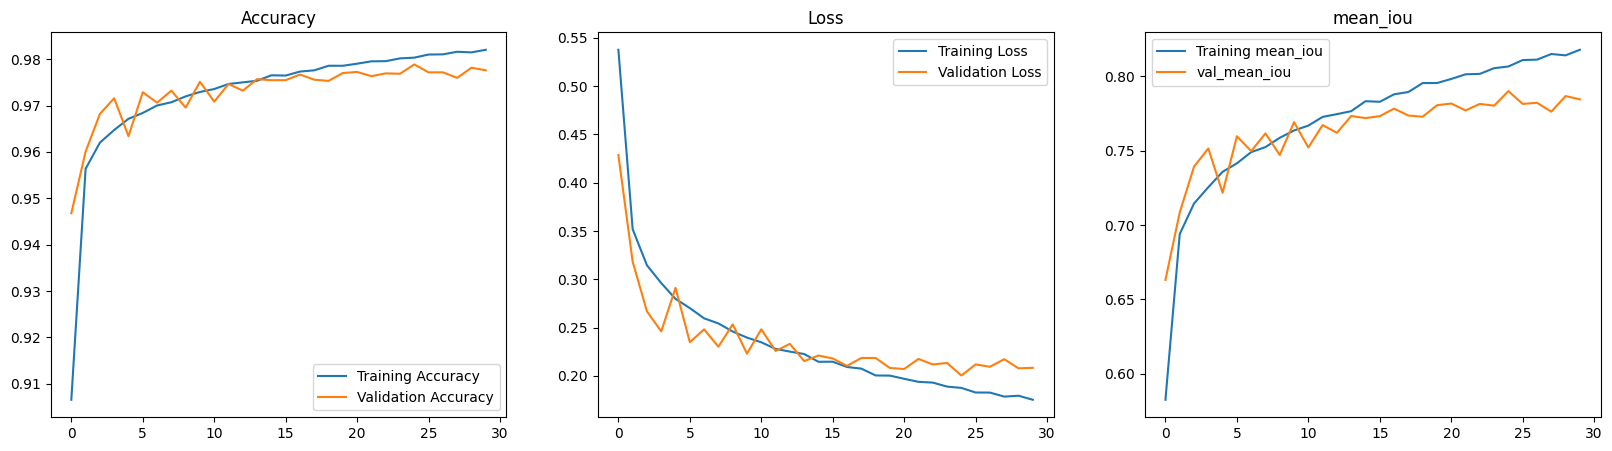

In [46]:
plt.figure(figsize=(20, 5))
plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history.history['mean_io_u'], label='Training mean_iou')
plt.plot(history.history['val_mean_io_u'], label='val_mean_iou')
plt.title('mean_iou')
plt.legend()

plt.show()

# Evaluation

In [47]:
custom_objects = {
    "combined_loss": combined_loss,
}


best_model = tf.keras.models.load_model(
    './bestmodel.keras',
    custom_objects=custom_objects
)

In [48]:
def predict_and_visualize(model, image_path, mask_path, img_size=(256, 256), confidence_threshold=0.6):
   
    img = tf.io.read_file(image_path)
    img = tf.image.decode_png(img, channels=3)
    img_resized = tf.image.resize(img, img_size)
    
    img_for_display = img_resized
    
    img_preprocessed = preprocess_input(img_resized)
    img_for_prediction = tf.expand_dims(img_preprocessed, axis=0)

    prediction = model.predict(img_for_prediction)

    max_probs = np.max(prediction, axis=-1)

    predicted_labels = np.argmax(prediction, axis=-1)

    predicted_mask = np.where(max_probs < confidence_threshold, 0, predicted_labels)

    predicted_mask = np.squeeze(predicted_mask)

    _, true_mask_tensor = load_image_and_mask(image_path, mask_path)
    true_mask = np.squeeze(true_mask_tensor.numpy())
    
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.title("Original Image")
    plt.imshow(img_for_display / 255.0)
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("True Mask")
    plt.imshow(true_mask, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title(f"Predicted Mask (Threshold={confidence_threshold})")
    plt.imshow(predicted_mask, cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()
    print(f"Unique values in True Mask: {np.unique(true_mask)}")
    print(f"Unique values in Predicted Mask: {np.unique(predicted_mask)}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step


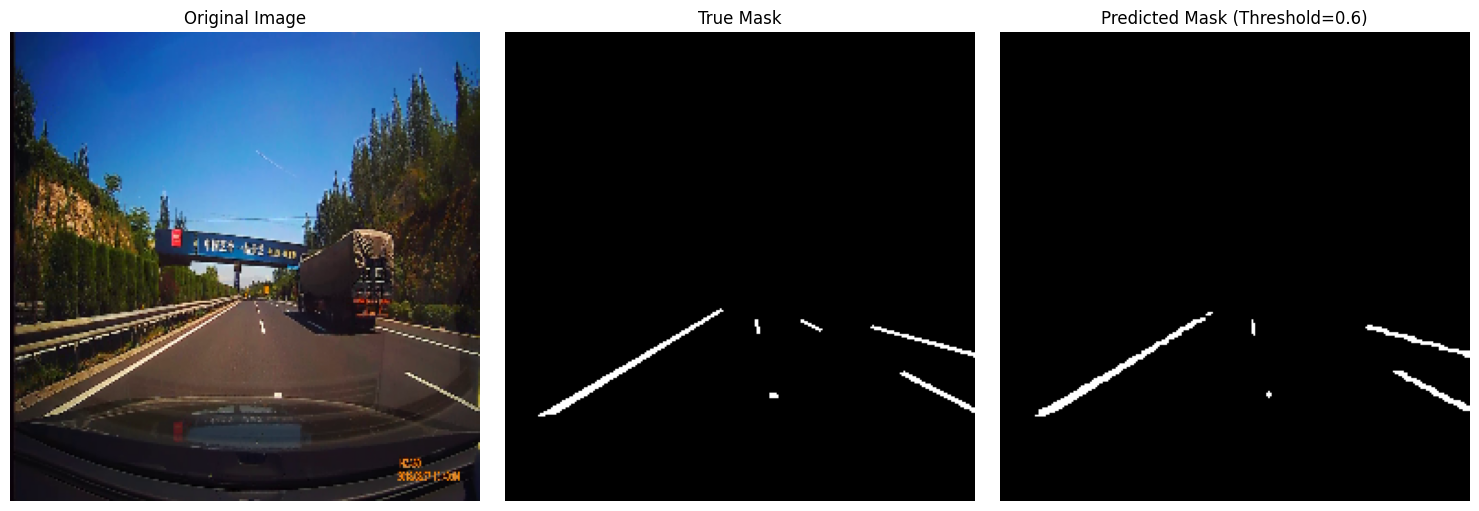

Unique values in True Mask: [0 1]
Unique values in Predicted Mask: [0 1]


In [55]:
sample_index = 100

sample_image_path = val_images[sample_index]
sample_mask_path = val_masks[sample_index]

predict_and_visualize(best_model, sample_image_path, sample_mask_path)